In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\jaked\Downloads\Churn Prediction\data\Customer-Churn-Records.csv")
df.shape
df.head(1)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1,1,2,DIAMOND,464


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
df.describe(include = "all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DIAMOND,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,NaN,606.515100
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,NaN,225.924839
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,NaN,119.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,NaN,410.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,NaN,605.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,NaN,801.000000


We can see that the most columns don't have a multiple categories, however, for the one with 2 (Gender) let's just do binary encoding and for the Geography and Card Type let's do One-Hot Encoding.

In [17]:
df["Gender"] = df["Gender"].replace({"Male": 1, "Female": 0}).astype(int)

In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,0,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,0,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [9]:
multi_cat_cols = ["Geography", "Card Type"]
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)

In [10]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,1,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,1,2,464,False,False,False,False,False
1,2,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,1,3,456,False,True,False,False,False
2,3,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,1,3,377,False,False,False,False,False
3,4,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,0,5,350,False,False,True,False,False
4,5,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,0,5,425,False,True,True,False,False


Lets do some cleaning

In [11]:
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df.describe(include = "all")

,RowNumber,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
count,"10,000.00","10,000.00",10000,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00",10000,10000,10000,10000,10000
unique,NaN,NaN,2932,NaN,2.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,Smith,NaN,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False
freq,NaN,NaN,32,NaN,"5,457.00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7491,7523,7498,7505,7504
mean,"5,000.50","15,690,940.57",NaN,650.53,NaN,38.92,5.01,"76,485.89",1.53,0.71,0.52,"100,090.24",0.20,0.20,3.01,606.52,NaN,NaN,NaN,NaN,NaN
std,"2,886.90","71,936.19",NaN,96.65,NaN,10.49,2.89,"62,397.41",0.58,0.46,0.50,"57,510.49",0.40,0.40,1.41,225.92,NaN,NaN,NaN,NaN,NaN
min,1.00,"15,565,701.00",NaN,350.00,NaN,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.00,0.00,1.00,119.00,NaN,NaN,NaN,NaN,NaN
25%,"2,500.75","15,628,528.25",NaN,584.00,NaN,32.00,3.00,0.00,1.00,0.00,0.00,"51,002.11",0.00,0.00,2.00,410.00,NaN,NaN,NaN,NaN,NaN
50%,"5,000.50","15,690,738.00",NaN,652.00,NaN,37.00,5.00,"97,198.54",1.00,1.00,1.00,"100,193.91",0.00,0.00,3.00,605.00,NaN,NaN,NaN,NaN,NaN
75%,"7,500.25","15,753,233.75",NaN,718.00,NaN,44.00,7.00,"127,644.24",2.00,1.00,1.00,"149,388.25",0.00,0.00,4.00,801.00,NaN,NaN,NaN,NaN,NaN


In [12]:
df = df.drop("CustomerId", axis = 1)

In [14]:
df = df.drop("Surname", axis = 1)

In [27]:
df =  df.drop("RowNumber", axis = 1)

In [31]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Gender              10000 non-null  int64  
 2   Age                 10000 non-null  int64  
 3   Tenure              10000 non-null  int64  
 4   Balance             10000 non-null  float64
 5   NumOfProducts       10000 non-null  int64  
 6   HasCrCard           10000 non-null  int64  
 7   IsActiveMember      10000 non-null  int64  
 8   EstimatedSalary     10000 non-null  float64
 9   Exited              10000 non-null  int64  
 10  Complain            10000 non-null  int64  
 11  Satisfaction Score  10000 non-null  int64  
 12  Point Earned        10000 non-null  int64  
 13  Geography_Germany   10000 non-null  int64  
 14  Geography_Spain     10000 non-null  int64  
 15  Card Type_GOLD      10000 non-null  int64  
 16  Card Type_PLATIN

In [29]:
corr_matrix = df.corr(numeric_only = True)
churn_corr = corr_matrix["Exited"].sort_values(ascending = False)
print(churn_corr)

Exited                1.00
Complain              1.00
Age                   0.29
Geography_Germany     0.17
Balance               0.12
EstimatedSalary       0.01
Card Type_PLATINUM   -0.00
Card Type_SILVER     -0.00
Point Earned         -0.00
Satisfaction Score   -0.01
HasCrCard            -0.01
Tenure               -0.01
Card Type_GOLD       -0.02
CreditScore          -0.03
NumOfProducts        -0.05
Geography_Spain      -0.05
Gender               -0.11
IsActiveMember       -0.16
Name: Exited, dtype: float64


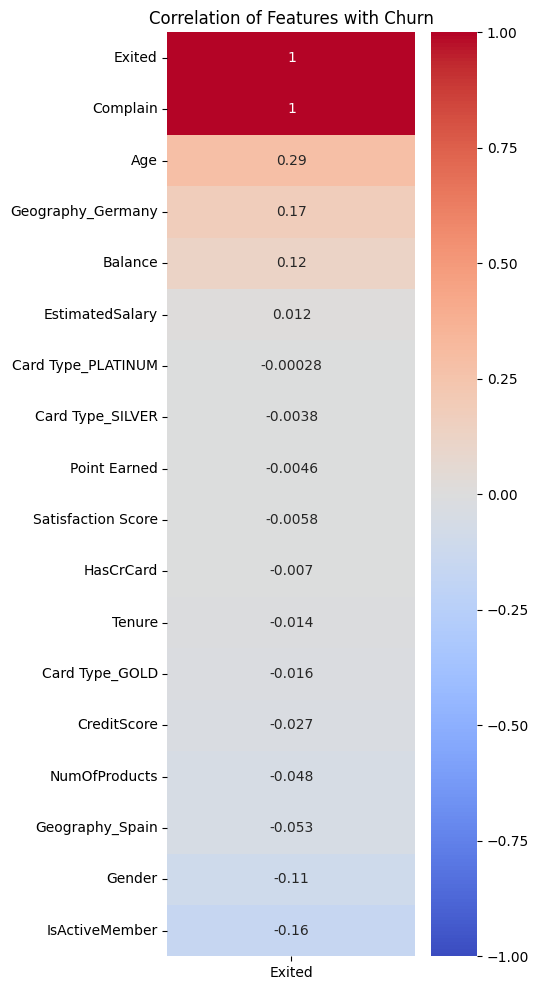

In [28]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix["Exited"].sort_values(ascending= False)

plt.figure(figsize = (4,12))
sns.heatmap(churn_corr.to_frame(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation of Features with Churn")
plt.show()

Negative Churn

    IsActiveMember (-0.16) : Customers who are active members of the bank are less likely to churn
    NumOfProducts (-0.048) : Customers who are buying a lot using the bank are less likely to churn
    Geography_Spain (-0.053) : Customers who are located in Spain are less likely to churn

Positive Churn

    Complain (1) : Customers with a history of complaints have a high likelyhood to churn
    Age (0.29) : Depending on the age of the customer, they are more likely to churn
    Geography_Germany (0.17) : Customers in Germany are more likely to churn

Now lets look for multicollinearity

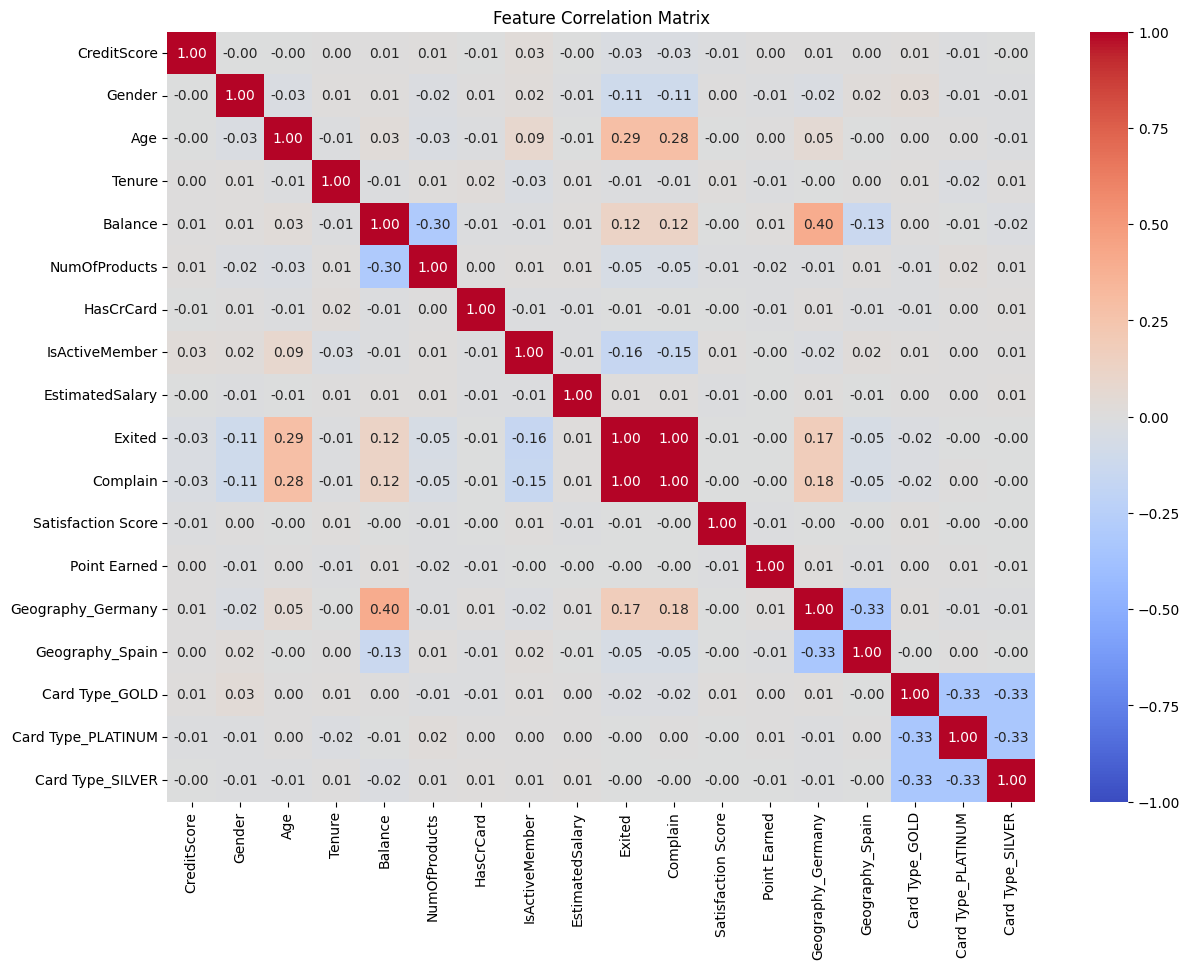

In [35]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

In [36]:
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

features = df.drop(columns=["Exited"]).select_dtypes(include="number")

vif_data = pd.DataFrame()
vif_data["Feature"] = features.columns
vif_data["VIF"] = [variance_inflation_factor(features.values, i) for i in range(features.shape[1])]

print(vif_data.sort_values("VIF", ascending=False))

               Feature   VIF
0          CreditScore 25.14
2                  Age 14.12
5        NumOfProducts  7.99
11        Point Earned  7.57
10  Satisfaction Score  5.30
8      EstimatedSalary  3.91
3               Tenure  3.90
6            HasCrCard  3.30
4              Balance  3.21
1               Gender  2.20
7       IsActiveMember  2.15
14      Card Type_GOLD  1.97
16    Card Type_SILVER  1.96
15  Card Type_PLATINUM  1.96
12   Geography_Germany  1.82
13     Geography_Spain  1.49
9             Complain  1.48


VIF < 5 → no problem
VIF 5–10 → moderate multicollinearity, worth investigating
VIF > 10 → high multicollinearity, consider dropping that feature

-We have some features that need to be investigated in order to decide whether to drop usee regularizatrion
-Or We can use a tree based solution which is less sensitive to multicollinearity

In [37]:
df["Exited"].value_counts()

Exited
0    7962
1    2038
Name: count, dtype: int64

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report
import pandas as pd
import time

x = df.drop(columns= ["Exited"])
y = df["Exited"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify=y)

THRESHOLD = 0.3

Let's test a RandomForrest Classifier

In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators= 300, class_weight="balanced", random_state= 42, n_jobs= -1)
rf.fit(x_train, y_train)

proba = rf.predict_proba(x_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits = 3)) 

              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000



In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(x_test)[:, 1]

print("Threshold Tuning for RandomForest")

print(f"{"thresh": <8}{"Prec_1": <8}{"Rec_1":<8}{"F1_1":<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")
      

Threshold Tuning for RandomForest
thresh  Prec_1  Rec_1   F1_1    
0.25    0.998   0.995   0.996   
0.3     0.998   0.995   0.996   
0.35    0.998   0.995   0.996   
0.4     0.998   0.995   0.996   
0.45    0.998   0.995   0.996   
0.5     0.998   0.995   0.996   


Let's test a LightGBM Classifier

In [51]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
lgbm.fit(x_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = lgbm.predict_proba(x_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000197 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = lgbm.predict_proba(x_test)[:, 1]

print("Threshold tuning for LightGBM")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for LightGBM
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.995   0.995   0.995   
0.3     0.995   0.995   0.995   
0.35    0.995   0.995   0.995   
0.4     0.995   0.995   0.995   
0.45    0.995   0.995   0.995   
0.5     0.995   0.995   0.995   


Finally, lets test a XGBoost Classifier

In [55]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

# Training timer
start_train = time.time()
xgb.fit(x_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

# Prediction timer
start_pred = time.time()
proba = xgb.predict_proba(x_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

# Classification report
print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.19 seconds
⏱ Prediction time: 0.0042 seconds
              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000



In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = xgb.predict_proba(x_test)[:, 1]

print("Threshold tuning for XGBoost")

print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label=1)
    rec = recall_score(y_test, preds, pos_label=1)
    f1 = f1_score(y_test, preds, pos_label=1)
    print(f"{thresh:<8}{prec:<8.3f}{rec:<8.3f}{f1:<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.998   0.995   0.996   
0.3     0.998   0.995   0.996   
0.35    0.998   0.995   0.996   
0.4     0.998   0.995   0.996   
0.45    0.998   0.995   0.996   
0.5     0.998   0.995   0.996   


Given that all three models are performing nearly identitically across every threshold, we should use XGBoost due to the fact that it matches RandomCutForrest's performance while being faster. Also, due to this being a churn prediction, it handles class imbalance well and is the industry standard

While the F1 scores are already high at 0.996, it is still worth it to do Hyperparamter Tuning and Experiment Tracking 

In [61]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": (y_train == 0).sum() / (y_train == 1).sum(),
        "eval_metric": "logloss"
    }
    
    model = XGBClassifier(**params)
    model.fit(x_train, y_train)
    proba = model.predict_proba(x_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)  
    return recall_score(y_test, y_pred, pos_label=1)  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best Recall:", study.best_value)

[I 2026-03-28 16:00:33,775] A new study created in memory with name: no-name-2f8293b8-b619-43d8-b0ed-95e963f4b5fc
[I 2026-03-28 16:00:33,961] Trial 0 finished with value: 0.9950980392156863 and parameters: {'n_estimators': 412, 'learning_rate': 0.09864305515185517, 'max_depth': 3, 'subsample': 0.7775241304091973, 'colsample_bytree': 0.7411530392746093, 'min_child_weight': 10, 'gamma': 1.167235926925001, 'reg_alpha': 4.210398159159753, 'reg_lambda': 2.385746152600024}. Best is trial 0 with value: 0.9950980392156863.
[I 2026-03-28 16:00:34,282] Trial 1 finished with value: 0.9950980392156863 and parameters: {'n_estimators': 794, 'learning_rate': 0.04293110553898616, 'max_depth': 5, 'subsample': 0.8384266023412097, 'colsample_bytree': 0.5223092961220757, 'min_child_weight': 9, 'gamma': 0.6709859942880975, 'reg_alpha': 4.759725692126126, 'reg_lambda': 2.276271138141989}. Best is trial 0 with value: 0.9950980392156863.
[I 2026-03-28 16:00:34,386] Trial 2 finished with value: 0.9950980392156

Best Params: {'n_estimators': 412, 'learning_rate': 0.09864305515185517, 'max_depth': 3, 'subsample': 0.7775241304091973, 'colsample_bytree': 0.7411530392746093, 'min_child_weight': 10, 'gamma': 1.167235926925001, 'reg_alpha': 4.210398159159753, 'reg_lambda': 2.385746152600024}
Best Recall: 0.9950980392156863


In [62]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

best_params = study.best_params
best_params.update({
    "random_state": 42,
    "n_jobs": -1,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss"
})

xgb = XGBClassifier(**best_params)

start_train = time.time()
xgb.fit(x_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = xgb.predict_proba(x_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.4f} seconds")

print(classification_report(y_test, y_pred, digits=3))

⏱ Training time: 0.10 seconds
⏱ Prediction time: 0.0033 seconds
              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000



In [ ]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, roc_auc_score
import time
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlruns/mlflow.db")
mlflow.set_experiment("Telco Churn - XGBoost")

with mlflow.start_run():

    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    best_params = study.best_params
    best_params.update({
        "random_state": 42,
        "n_jobs": -1,
        "scale_pos_weight": scale_pos_weight,
        "eval_metric": "logloss"
    })

    mlflow.log_params(best_params)
    mlflow.log_param("threshold", THRESHOLD)

    start_train = time.time()
    xgb = XGBClassifier(**best_params)
    xgb.fit(x_train, y_train)
    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)
    print(f"⏱ Training time: {train_time:.2f} seconds")

    start_pred = time.time()
    proba = xgb.predict_proba(x_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)
    print(f"⏱ Prediction time: {pred_time:.4f} seconds")

    precision = precision_score(y_test, y_pred, pos_label=1)
    recall = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    auc = roc_auc_score(y_test, proba)

    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("roc_auc", auc)

    mlflow.xgboost.log_model(xgb, "model")

    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {auc:.4f}")

2026/03/28 16:16:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/28 16:16:55 INFO mlflow.store.db.utils: Updating database tables
2026/03/28 16:16:56 INFO mlflow.tracking.fluent: Experiment with name 'Telco Churn - XGBoost' does not exist. Creating a new experiment.
2026/03/28 16:16:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


⏱ Training time: 0.10 seconds
⏱ Prediction time: 0.0028 seconds
              precision    recall  f1-score   support

           0      0.999     0.999     0.999      1592
           1      0.998     0.995     0.996       408

    accuracy                          0.999      2000
   macro avg      0.998     0.997     0.998      2000
weighted avg      0.998     0.999     0.998      2000

ROC-AUC: 0.9985


Class 0 (Not Churned) - 1592 Customers 
    - Precision 0.999 — when it predicts someone won't churn, it's right 99.9% of the time
    - Recall 0.999 — it correctly identifies 99.9% of all non-churners

Class 1 (Churned) - 408 Customers
    - Precision 0.998 — when it flags someone as a churner, it's right 99.8% of the time
    - Recall 0.995 — it catches 99.5% of all actual churners, missing only ~2 people

ROC-AUC: 0.9985
    - This is the most important number for a churn model. At 0.9985, it means the model has near-perfect ability to distinguish between churners and non-churners across all thresholds.